In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import ( 
 col, to_date,  lit, mean as _mean, date_format)
from typing import List, Dict, Tuple
import glob
import gzip
from functools import reduce
import re # Added for the regex file read helper


In [12]:
# --- 1. Spark Session Initialization ---
spark = SparkSession.builder.appName("AirbnbPriceAnalysisSpark").getOrCreate()
print(f"Spark Version: {spark.version}")

Spark Version: 4.0.0-preview2


In [13]:
# --- CONFIGURATION ---
COLUMN = "price"
BASE_DIR = "" # IMPORTANT: Adjust this to your data root, e.g., "/mnt/data/"
# --- ADDED PATH_PREFIX ---
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2021-12-31"

# --- UPDATED CITY_CONFIGS to match availability file ---
CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city", # Full path for globbing
        "regex_key": "united-states/ny/new-york-city",               # Key for date extraction regex
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin",
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles",
    },
]

In [14]:
# -------------------------------------------------------------
# Per-city: collect daily means using Spark
# -------------------------------------------------------------
def collect_daily_mean_spark(
    spark: SparkSession, city_config: Dict, column: str, base_dir: str, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Reads data for a single city, calculates the daily mean for the column, 
    and filters by the date range using Spark.
    
    Returns a Pandas DataFrame of daily means.
    """
    label = city_config["label"]
    # UPDATED: Use the new root_path and regex_key
    root_path = city_config["root_path"]
    regex_key = city_config["regex_key"]
    daily_mean_col = f"{column}_mean"
    
    # --- 1. Read Files ---
    # UPDATED: Glob pattern uses root_path
    glob_pattern = f"{base_dir}/{root_path}/*/visualisations/listings.csv"
    
    try:
        # Spark reads all matching files
        df = (
            spark.read
            .option("header", True)
            .option("inferSchema", True)
            .csv(glob_pattern)
            .withColumn("source_file", input_file_name())
        )
    except Exception as e:
        print(f"[{label}] Error reading data: {e}")
        return pd.DataFrame()

    if df.rdd.isEmpty():
        print(f"[{label}] No data in files.")
        return pd.DataFrame()

    # --- 2. Extract Date and Filter ---
    # UPDATED: Regex uses regex_key
    # The regex key is the full directory path segment preceding the date folder.
    date_pattern = rf"/{regex_key}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"
    
    df = (
        df.withColumn("date_str", regexp_extract(col("source_file"), date_pattern, 1))
          .withColumn("date", to_date(col("date_str"), "yyyy-MM-dd"))
          .drop("date_str")
    )
    
    # Drop rows missing date or the target column
    df = df.dropna(subset=["date", column])

    # Date range filter
    df = df.filter(
        (col("date") >= lit(start_date)) & 
        (col("date") <= lit(end_date))
    )
    
    # Safely cast the price column to double and filter for positive values
    df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
    df = df.filter(col(column) > 0).filter(col(column).isNotNull())


    # --- 3. Aggregate Daily Mean ---
    daily = (
        df.groupBy("date")
          .agg(_mean(column).alias(daily_mean_col))
          .withColumn("city_label", lit(label))
          .withColumn("month", date_format(col("date"), "yyyy-MM"))
          .orderBy("date")
    )
    
    # Return the final daily aggregated result as a Pandas DataFrame
    return daily.toPandas()


# -------------------------------------------------------------
# Per-city: aggregate daily → monthly (mean of daily means) using Spark
# -------------------------------------------------------------
def aggregate_to_months_mean_spark(daily_df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Aggregates a Pandas DataFrame of daily means into a monthly mean 
    using Spark for efficient grouping.
    """
    if daily_df.empty:
        return pd.DataFrame()

    daily_mean_col = f"{column}_mean"
    monthly_mean_col = f"{column}_mean_month"

    # Create a Spark DataFrame from the Pandas DataFrame
    spark_df = spark.createDataFrame(daily_df)
    
    # Group by city and month, then calculate the mean of the daily means
    month_df_spark = (
        spark_df.groupBy("city_label", "month")
        .agg(_mean(daily_mean_col).alias(monthly_mean_col))
        .sort("city_label", "month")
        .drop("city_label") # Drop before conversion to match original function output
    )
    
    # Convert the result back to Pandas
    month_df = month_df_spark.toPandas()
    return month_df

In [ ]:
# -------------------------------------------------------------
# Plot multiple cities on one graph (Unchanged)
# -------------------------------------------------------------
def plot_multi_city_monthly_mean(city_results, column,
                                 outfile="images/monthly_price_mean.png"):

    plt.figure(figsize=(12, 6))

    # --- Add vertical marker lines HERE ---
    IMPORTANT_DATES = [
        "2020-05-10",   # WHO pandemic declaration
        "2021-01-01",   # example date
    ]

    for d in IMPORTANT_DATES:
        dt = pd.to_datetime(d)
        plt.axvline(dt, color="red", linestyle="--", linewidth=1)
        plt.text(dt, 0, d, rotation=90, verticalalignment="bottom")
    # --------------------------------------

    for label, month_df in city_results:
        if month_df.empty:
            print(f"Skipping plot for {label}: no data.")
            continue

        df = month_df.copy()
        df["month_dt"] = pd.to_datetime(df["month"])
        col_name = f"{column}_mean_month"     # <---- correct column

        plt.plot(df["month_dt"], df[col_name], marker="o", label=label)

    plt.title("Monthly Average Price by City")
    plt.xlabel("Month")
    plt.ylabel("Average Price")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()

    print(f"Saved figure to {outfile}")



In [ ]:
# -------------------------------------------------------------
# MAIN
# -------------------------------------------------------------
if __name__ == "__main__":
    city_results = []

    for cfg in CITY_CONFIGS:
        label = cfg['label']
        print(f"\n=== Processing {cfg['label']} ===")
        
        # --- 1. Spark Processing: DAILY Mean ---
        # Returns a Pandas DataFrame (daily means)
        daily_df = collect_daily_mean_spark(
            spark=spark,
            city_config=cfg,
            column=COLUMN,
            base_dir=BASE_DIR,
            start_date=START_DATE,
            end_date=END_DATE,
        )

        print(f"{cfg['label']} daily rows:", len(daily_df))

        if daily_df.empty:
            city_results.append((cfg["label"], pd.DataFrame()))
            continue

        # --- 2. Spark Processing: MONTHLY Mean ---
        # Takes Pandas daily DF, aggregates using Spark, returns Pandas monthly DF
        monthly = aggregate_to_months_mean_spark(daily_df, COLUMN)
        
        print(f"{cfg['label']} monthly rows:", len(monthly))
        print(monthly.head())

        city_results.append((cfg["label"], monthly))

    # Plot comparison
    plot_multi_city_monthly_mean(city_results, COLUMN)
    
    # Stop the Spark session when done
    spark.stop()


=== Processing new-york-city ===


Skipping plot for new-york-city: no data.
Skipping plot for austin: no data.
Skipping plot for los-angeles: no data.


/tmp/ipykernel_32950/420372080.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


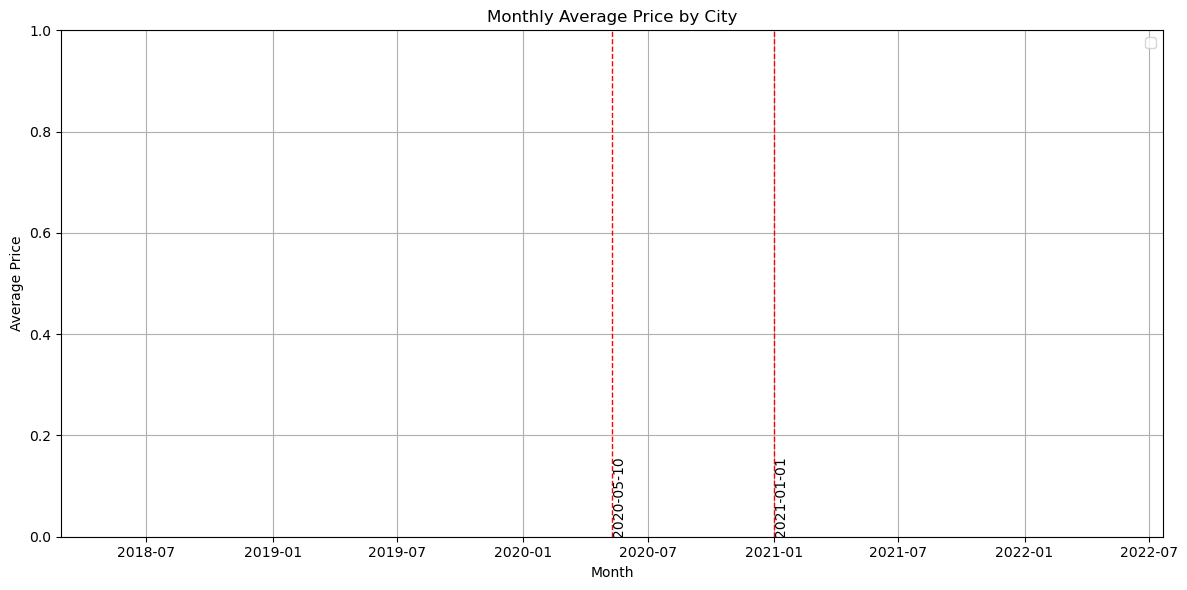

Saved figure to monthly_price_mean.png


In [8]:
# Plot comparison
plot_multi_city_monthly_mean(city_results, COLUMN)

# Stop the Spark session when done
spark.stop()